# Ratio-variable predictors: PA size and Mortality

This workbook walks through STATA code evaluate the influence of using PA:AA as a mortality predictor

## Objective: 

Pulmonary artery diameter on CT scan is a prognostic factor, indicating a higher risk of death when enlarged. 

However, body size is a nuissance variable in this evaluation (ie. we don't care about it per se, but want to control for it's relationship with PA size). 

On an absolute scale, the pulmonary artery might be large because: 

1. The patient has pulmonary hypertension, and pulmonary hypertension is associated with death. 
2. They are a larger person, so everything is larger (likely, not associated with death)
3. They are obese, and pulmonary blood flow / thoracic blood volume is larger (may be associated with death through nonspecific mechanicms)

The pulmonary artery to ascending aortic ratio was intended to allow for control of this. (Ng et al. proposed the PA:AA ratio as a CT sign of pulmonary arterial hypertension 
- https://pubmed.ncbi.nlm.nih.gov/10524808/ - the ratio correlated with mean PA pressure and, unlike absolute PA diameter, showed no association with body surface area (BSA))  

By normalizing the PA size to the Ascending aorta size, it accounts for body size (as well as other nuisance variables, like cardiac cycle and image acquisition technique) - A widely cited ATS review stated the aorta serves as an "internal normalization," effectively correcting for BSA, sex, age, cardiac‑cycle phase, and technical factors—i.e., normalization beyond body size alone. 
https://pmc.ncbi.nlm.nih.gov/articles/PMC4298979/

However, both the PA diameter and the Ascending Aorta are influence by age, sex, and comorbidity profiles (which may be distinct). New population analyses questioned the interpretability of PA:AA when aortic caliber varies, arguing that dependence on AA complicates biological meaning and risk signals. This reinforces that the ratio is not a body‑size index per se, but a relative vascular‑caliber measure influenced by aortic remodeling. https://pubmed.ncbi.nlm.nih.gov/38637237/


If AA just functions as a normalization for body size, encoding that information as a single ratio may not discard much information, but if both the PA and the AA encode independent prognostic information, collapsing that down to a single ratio would be potentially misleading.

For example, a normal PA:AA ratio might result from several scenarios, which each potentially having different prognostic implication:
- a small PA and small AA 
- a normal PA and normal AA, 
- or a large PA and a large AA

We previously reported that both PAd and PA:AA were associated with mortality risk in a cohort of patients who'd receive PA imaging in an emergency room setting. (https://onlinelibrary.wiley.com/doi/10.1002/pul2.12225). In this investigation, we seek re-analyze this data to evaluate whether AA diameter encode additional prognostic information to body size, and whether PA and AA size ought to be modeled separately. 

1. Are Cox regression models for hazard of adjusting for age and sex more accurate using PA:AA as a predictor than PA:height, PA:Weight, PA:BMI, PA:BSA, or PA:(Height and Weight)?
2. Are Cox regression models for hazard of death adjusting for PAd, PA:AA substantially less predictive than models that independently model PA and AA


### References for the framing: 

- Prognostic Factor research recommendations: https://bmjopen.bmj.com/content/15/8/e095065
- Ratio variables problematic as predictors: 
- Ratio variables problematic as outcomes: https://doi.org/10.1038/s41366-025-01732-6 

In [1]:
%pip install stata_setup
import stata_setup
stata_setup.config(r"/Applications/Stata/", "be")

Note: you may need to restart the kernel to use updated packages.

  ___  ____  ____  ____  ____ ®
 /__    /   ____/   /   ____/      Stata 18.0
___/   /   /___/   /   /___/       BE—Basic Edition

 Statistics and Data Science       Copyright 1985-2023 StataCorp LLC
                                   StataCorp
                                   4905 Lakeway Drive
                                   College Station, Texas 77845 USA
                                   800-782-8272        https://www.stata.com
                                   979-696-4600        service@stata.com

Stata license: 35-user network perpetual
Serial number: 301806305068
  Licensed to: Brian Locke
               University of Utah

Notes:
      1. Unicode is supported; see help unicode_advice.


In [2]:
%%stata

cd "/Users/blocke/Box Sync/Residency Personal Files/Scholarly Work/Locke Research Projects/Pulm Artery Stuff w Scarps/Local Analysis"
//cd "/Users/reblocke/Research/CTPA-Dose-Response"

capture mkdir "Results and Figures"
capture mkdir "Results and Figures/$S_DATE/" //make new folder for figure output if needed
capture mkdir "Results and Figures/$S_DATE/Logs/" //new folder for stata logs
local a1=substr(c(current_time),1,2)
local a2=substr(c(current_time),4,2)
local a3=substr(c(current_time),7,2)
//local b = "Body-size Analysis.do" // do file name
//copy "`b'" "Results and Figures/$S_DATE/Logs/(`a1'_`a2'_`a3')`b'"

clear
set scheme cleanplots //cleanplots white_tableau white_w3d //3 options I usually use

use cleaned_noempi


. 
. cd "/Users/blocke/Box Sync/Residency Personal Files/Scholarly Work/Locke Rese
> arch Projects/Pulm Artery Stuff w Scarps/Local Analysis"
/Users/blocke/Box Sync/Residency Personal Files/Scholarly Work/Locke Research P
> rojects/Pulm Artery Stuff w Scarps/Local Analysis

. //cd "/Users/reblocke/Research/CTPA-Dose-Response"
. 
. capture mkdir "Results and Figures"

. capture mkdir "Results and Figures/$S_DATE/" //make new folder for figure out
> put if needed

. capture mkdir "Results and Figures/$S_DATE/Logs/" //new folder for stata logs

. local a1=substr(c(current_time),1,2)

. local a2=substr(c(current_time),4,2)

. local a3=substr(c(current_time),7,2)

. //local b = "Body-size Analysis.do" // do file name
. //copy "`b'" "Results and Figures/$S_DATE/Logs/(`a1'_`a2'_`a3')`b'"
. 
. clear

. set scheme cleanplots //cleanplots white_tableau white_w3d //3 options I usua
> lly use

. 
. use cleaned_noempi

. 


goal 1: describe the population

Relevant covariates: 

PA size (probably want to separate on this by tertile, and a summary paragraph)

- mpad
- age
- male 
- height
- weight
- bmi
- death
- time of death

(also comorbidities, for supplement)

### Table 1

In [3]:
%%stata
table1_mc, by (mpad_tertile) ///
vars( ///
mpad conts %4.1f \ ///
age conts %4.1f \ ///
male bin %4.1f \ /// 
height conts %4.1f \ ///
weight conts %4.1f \ ///
bmi conts %4.1f \ /// 
bsa_mosteller conts %4.2f \ ///
ascendingaorta conts %4.1f \ ///
death bin %4.1f \ /// 
time_of_death conts %4.1f \ ///
time_of_censoring conts %4.1f \ ///
) ///
percent_n percsign("%") iqrmiddle(",") sdleft(" (±") sdright(")") onecol total(before) ///
saving("Results and Figures/$S_DATE/Table 1 Baseline chars by PA tertile.xlsx", replace)



. table1_mc, by (mpad_tertile) ///
> vars( ///
> mpad conts %4.1f \ ///
> age conts %4.1f \ ///
> male bin %4.1f \ /// 
> height conts %4.1f \ ///
> weight conts %4.1f \ ///
> bmi conts %4.1f \ /// 
> bsa_mosteller conts %4.2f \ ///
> ascendingaorta conts %4.1f \ ///
> death bin %4.1f \ /// 
> time_of_death conts %4.1f \ ///
> time_of_censoring conts %4.1f \ ///
> ) ///
> percent_n percsign("%") iqrmiddle(",") sdleft(" (±") sdright(")") onecol tota
> l(before) ///
> saving("Results and Figures/$S_DATE/Table 1 Baseline chars by PA tertile.xlsx
> ", replace)

  +----------------------------------------------------------------------------
> -----+
  | factor                            N_T   N_1   N_2   N_3   m_T   m_1   m_2  
>  m_3 |
  |----------------------------------------------------------------------------
> -----|
  | MPAD                              990   336   336   318     0     0     0  
>    0 |
  |----------------------------------------------------------------------------

#### Table 1 supplemental - comorbid conditions

In [4]:
%%stata
table1_mc, by (mpad_tertile) ///
vars( ///
pulmdisease bin %4.1f \ /// 
chf bin %4.1f \ /// 
diabetes3 cat %4.1f \ /// 
hypertension bin %4.1f \ ///
pulmonarycircdisorders bin %4.1f \ /// 
peripheralvascdisorders bin %4.1f \ /// 
renalfailure bin %4.1f \ /// 
anyemergency bin %4.1f \ /// 
anyadmission bin %4.1f \ /// 
death bin %4.1f \ /// 
time_of_death conts %4.1f \ /// 
time_of_censoring conts %4.1f \ /// 
) ///
percent_n percsign("%") iqrmiddle(",") sdleft(" (±") sdright(")") onecol total(before) ///
saving("Results and Figures/$S_DATE/Table s1 comorbs and utilization by PA tertile.xlsx", replace)


. table1_mc, by (mpad_tertile) ///
> vars( ///
> pulmdisease bin %4.1f \ /// 
> chf bin %4.1f \ /// 
> diabetes3 cat %4.1f \ /// 
> hypertension bin %4.1f \ ///
> pulmonarycircdisorders bin %4.1f \ /// 
> peripheralvascdisorders bin %4.1f \ /// 
> renalfailure bin %4.1f \ /// 
> anyemergency bin %4.1f \ /// 
> anyadmission bin %4.1f \ /// 
> death bin %4.1f \ /// 
> time_of_death conts %4.1f \ /// 
> time_of_censoring conts %4.1f \ /// 
> ) ///
> percent_n percsign("%") iqrmiddle(",") sdleft(" (±") sdright(")") onecol tota
> l(before) ///
> saving("Results and Figures/$S_DATE/Table s1 comorbs and utilization by PA te
> rtile.xlsx", replace)

  +----------------------------------------------------------------------------
> ----------+
  | factor                                 N_T   N_1   N_2   N_3   m_T   m_1   
> m_2   m_3 |
  |----------------------------------------------------------------------------
> ----------|
  | Pulmonary Disease                      947   317   320   310   

## Section 1: Does the normalization of PA size to AA diameter encode prognostic information beyond body size?

In [5]:
%%stata
regress ascendingaorta height weight age i.male


      Source |       SS           df       MS      Number of obs   =       818
-------------+----------------------------------   F(4, 813)       =    161.94
       Model |  8459.25621         4  2114.81405   Prob > F        =    0.0000
    Residual |  10616.8705       813  13.0588813   R-squared       =    0.4434
-------------+----------------------------------   Adj R-squared   =    0.4407
       Total |  19076.1267       817  23.3489923   Root MSE        =    3.6137

------------------------------------------------------------------------------
ascendinga~a | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      height |   .0423051   .0144777     2.92   0.004     .0138871    .0707231
      weight |   .0435943   .0051217     8.51   0.000     .0335409    .0536476
         age |   .1475674   .0067296    21.93   0.000      .134358    .1607768
             |
        male |
       Male  |   1.5

***Interpretation:*** those predictors (weight, height, age, male - all assumed to be linear) explain 44.07% of the variation in ascending aorta size... the rest is not explained

In [6]:
%%stata
pcorr ascendingaorta height weight age i.male

(obs=818)

Partial and semipartial correlations of ascendingaorta with

               Partial   Semipartial      Partial   Semipartial   Significance
   Variable |    corr.         corr.      corr.^2       corr.^2          value
------------+-----------------------------------------------------------------
     height |   0.1019        0.0765       0.0104        0.0058         0.0036
     weight |   0.2860        0.2227       0.0818        0.0496         0.0000
        age |   0.6096        0.5737       0.3716        0.3292         0.0000
    0b.male | (dropped)
     1.male |   0.1656        0.1253       0.0274        0.0157         0.0000


***Interpretation:*** of the variance no explained by the other predictors, height explains 0.58% of the remaining variance in ascending aorta size, weight explains 4.96% of the variance, age explains 32.9% of the variance, and sex explains 1.5% of the variance.... ie., age is the strongest correalate of ascending aorta size.   (Semipartial correlation^2 is the relevant column)

In [7]:
%%stata
/* ===== Age+sex–adjusted comparison of PA normalizations (raw ratios) ===== */
preserve

* Analytic sample (assumes variables already exist & are cleaned)
drop if missing(mpad, ascendingaorta, age, male, height, weight, bmi, bsa, death, lastfollowupyear)

* Survival setup
stset lastfollowupyear, failure(death==1)

* Age spline (Harrell 10/50/90) and basis
quietly _pctile age, p(10 50 90)
local k_age `r(r1)' `r(r2)' `r(r3)'
capture drop age_rc*
mkspline2 age_rc = age, cubic knots(`k_age')

* ---------- Raw ratio predictors ----------
capture drop r_aa r_h r_w r_bmi r_bsa r_hw pa_hat_hw
gen double r_aa  = mpad/ascendingaorta
gen double r_h   = mpad/height
gen double r_w   = mpad/weight
gen double r_bmi = mpad/bmi
gen double r_bsa = mpad/bsa

* Both-size normalizer: PA divided by raw-units linear prediction from H+W
quietly regress mpad c.height c.weight
predict double pa_hat_hw, xb
replace pa_hat_hw = . if pa_hat_hw<=0
gen double r_hw = mpad/pa_hat_hw

* ---------- Fit each model; collect AIC/BIC/C into locals ----------
local rvars  "r_aa r_h r_w r_bmi r_bsa r_hw"
local names  `" "PA:AA" "PA:Height" "PA:Weight" "PA:BMI" "PA:BSA" "PA:(Ht,Wt)" "'

local i = 0
foreach R of local rvars {
    local ++i
    capture drop rc*
    mkspline2 rc = `R', cubic nknots(4)

    * Baseline: age-spline + sex
    quietly stcox c.(rc*) c.(age_rc*) i.male, vce(robust)

    quietly estat ic
    local A`i' = r(S)[1,5]
    local B`i' = r(S)[1,6]

    local C`i' = .
    capture noisily estat concordance
    if (_rc==0) local C`i' = r(C)
}

* ---------- Build a small results dataset and print ----------
clear
set obs 6
gen str16 model = ""
gen double AIC = . 
gen double BIC = .
gen double C   = .

local j = 0
foreach lbl of local names {
    local ++j
    replace model = `"`lbl'"' in `j'
    replace AIC   = `A`j''     in `j'
    replace BIC   = `B`j''     in `j'
    replace C     = `C`j''     in `j'
}

format AIC %9.3f BIC %9.3f C %6.4f
list, abbreviate(16) noobs sepby(model)

restore


. /* ===== Age+sex–adjusted comparison of PA normalizations (raw ratios) ===== 
> */
. preserve

. 
. * Analytic sample (assumes variables already exist & are cleaned)
. drop if missing(mpad, ascendingaorta, age, male, height, weight, bmi, bsa, de
> ath, lastfollowupyear)
(174 observations deleted)

. 
. * Survival setup
. stset lastfollowupyear, failure(death==1)

Survival-time data settings

         Failure event: death==1
Observed time interval: (0, lastfollowupyear]
     Exit on or before: failure

--------------------------------------------------------------------------
        816  total observations
         30  observations end on or before enter()
--------------------------------------------------------------------------
        786  observations remaining, representing
        243  failures in single-record/single-failure data
  6,113.529  total analysis time at risk and under observation
                                                At risk from t =         0
          

***Interpretation:*** all the PA diameter normalization strategies work roughly as well as one another in predicting hazard of death after adjusting for age and sex - with the best performaing model actually being PAd/BMI... though differences are small. 

## Part 2 : Does modeling PA size and AA size separately, as opposed to a ratio, improve estimation of mortality risk? 

Setup - restricted cubic splines allow predictors to take non-linear functional forms (see this intro: https://www.bmj.com/content/390/bmj-2024-082440). 

We'll compare two approaches: 

- model PA:AA ratio flexibly, assessing how various levels of PA:AA predict mortality risk.
- model PA flexibily, and AA flexibly - and use the model to make predictions about mortality risk. 
    - we'll asess whether this model is more accurate than the single model. 
    - if it is more accurate, and many patients with the same PA:AA ratio have very different predicted mortality risks, that would suggest that collapsing the PA and AA to a single PA:AA measure would be inadvisable.

### How does PA:AA predict risk? 


. preserve

. /* ==== PA:AA ratio curve (rcs-4); adj = rcs(age,3) + sex; xblc-safe ==== */
. 
. * Survival setup
. stset lastfollowupyear, failure(death==1)

Survival-time data settings

         Failure event: death==1
Observed time interval: (0, lastfollowupyear]
     Exit on or before: failure

--------------------------------------------------------------------------
        990  total observations
         78  observations end on or before enter()
--------------------------------------------------------------------------
        912  observations remaining, representing
        263  failures in single-record/single-failure data
  6,981.359  total analysis time at risk and under observation
                                                At risk from t =         0
                                     Earliest observed entry t =         0
                                          Last observed exit t =   12.4819

. 
. * Age spline (3 knots)
. capture drop age_rc*

. mkspline2 age_r

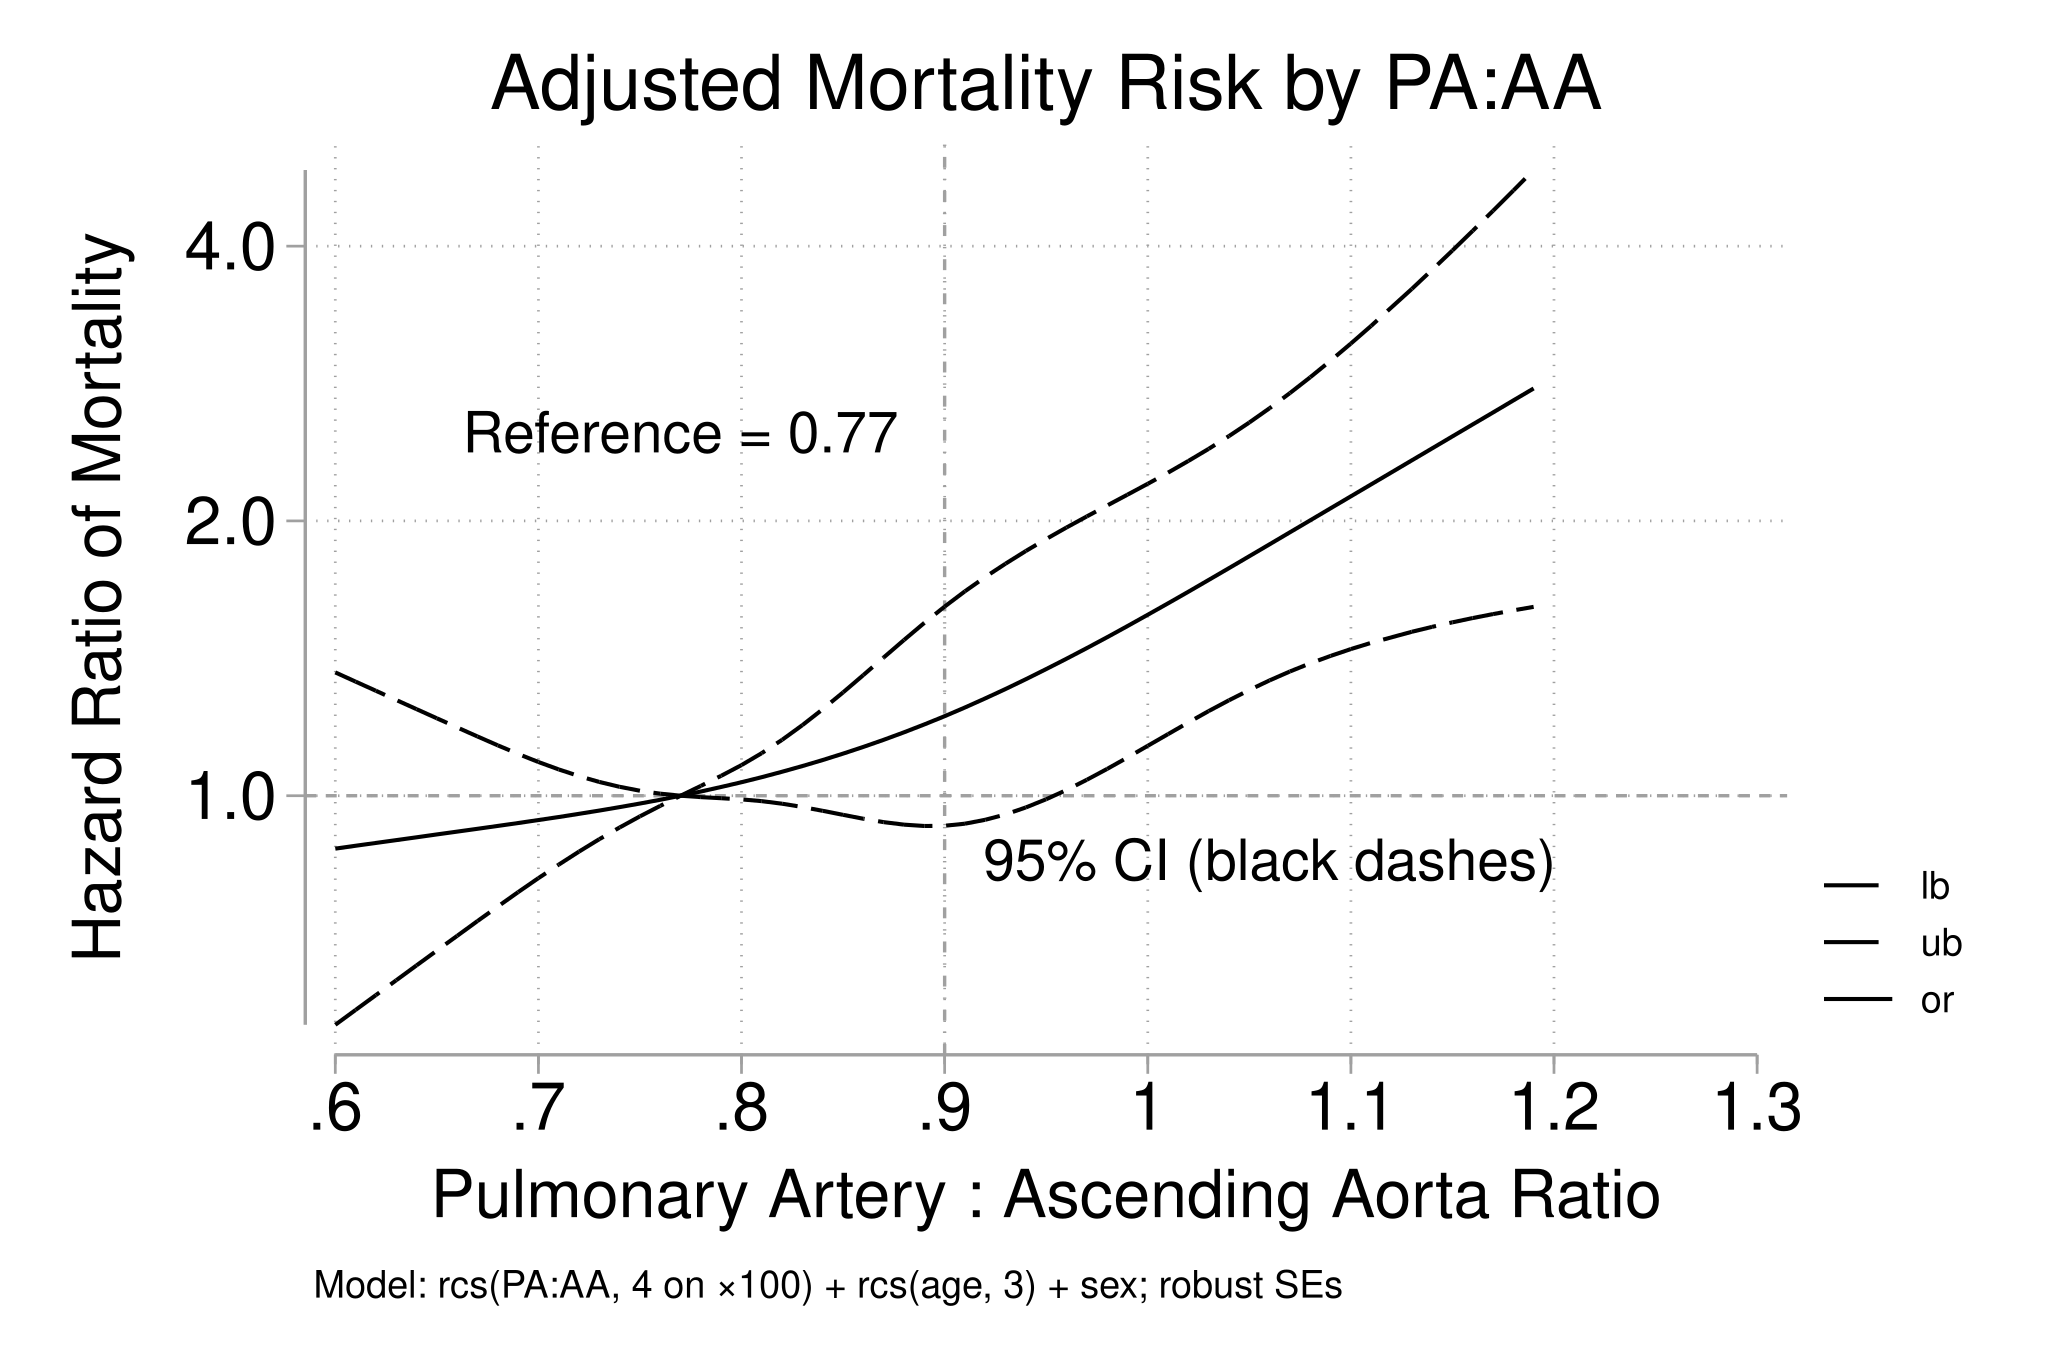

In [9]:
%%stata
preserve
/* ==== PA:AA ratio curve (rcs-4); adj = rcs(age,3) + sex; xblc-safe ==== */

* Survival setup
stset lastfollowupyear, failure(death==1)

* Age spline (3 knots)
capture drop age_rc*
mkspline2 age_rc = age, cubic nknots(3)

* Integerize PA:AA (e.g., 0.77 -> 77) to avoid binary-decimal issues
capture drop paaa100 rc*
gen long paaa100 = round(mpaaa*100)

* 4-knot spline of the predictor
mkspline2 rc = paaa100, cubic nknots(4)

* Cox model: rcs(PA:AA,4) + rcs(age,3) + sex   (NO ht/wt)
stcox c.(rc*) c.(age_rc*) i.male, vce(robust)
gen byte esample = e(sample)

* Range (p1–p99, clamped to 0.60–1.30)
quietly summarize mpaaa if esample, detail
local lo = ceil( max(r(p1)*100,  60) )
local hi = floor(min(r(p99)*100, 130) )

* Evaluate only at observed integerized values in-range
levelsof paaa100 if esample & inrange(paaa100, `lo', `hi'), local(atlist)

* Reference 0.77 => 77
xblc rc*, covname(paaa100) at(`atlist') reference(77) eform ///
     generate(pa or lb ub)

* Back to ratio scale
replace pa = pa/100

twoway ///
  (line lb ub pa, sort lc(black black) lp(longdash longdash)) ///
  (line or pa,   sort lc(black) lp(solid)), ///
  yscale(log extend) ///
  ylabel(1 2 4, angle(horiz) format(%2.1fc) labsize(large)) ///
  xlabel(0.6(0.1)1.3, labsize(large)) xmtick(0.6(0.1)1.3) ///
  ytitle("Hazard Ratio of Mortality", size(large)) ///
  xtitle("Pulmonary Artery : Ascending Aorta Ratio", size(large)) ///
  title("Adjusted Mortality Risk by PA:AA", size(vlarge)) ///
  note("Model: rcs(PA:AA, 4 on ×100) + rcs(age, 3) + sex; robust SEs", size(small)) ///
  yline(1, lp(shortdash) lc(gs10)) ///
  xline(0.9, lp(shortdash_dot) lc(gs10)) ///
  text(0.85 1.06 "95% CI (black dashes)", size(medlarge)) ///
  text(2.5  0.77 "Reference = 0.77", size(medlarge)) ///
  scheme(cleanplots)

restore

### Heatmap of the predictions of the flexibily modeled splines


. preserve

. /* ===== Heatmap: observed cells only | rcs(age,3); sex averaged | NO ht/wt =
> ==== */
. 
. * 1) Setup + knots
. stset lastfollowupyear, failure(death==1)

Survival-time data settings

         Failure event: death==1
Observed time interval: (0, lastfollowupyear]
     Exit on or before: failure

--------------------------------------------------------------------------
        990  total observations
         78  observations end on or before enter()
--------------------------------------------------------------------------
        912  observations remaining, representing
        263  failures in single-record/single-failure data
  6,981.359  total analysis time at risk and under observation
                                                At risk from t =         0
                                     Earliest observed entry t =         0
                                          Last observed exit t =   12.4819

. 
. capture drop mpad_rounded aa_rounded

. gen mpad_ro

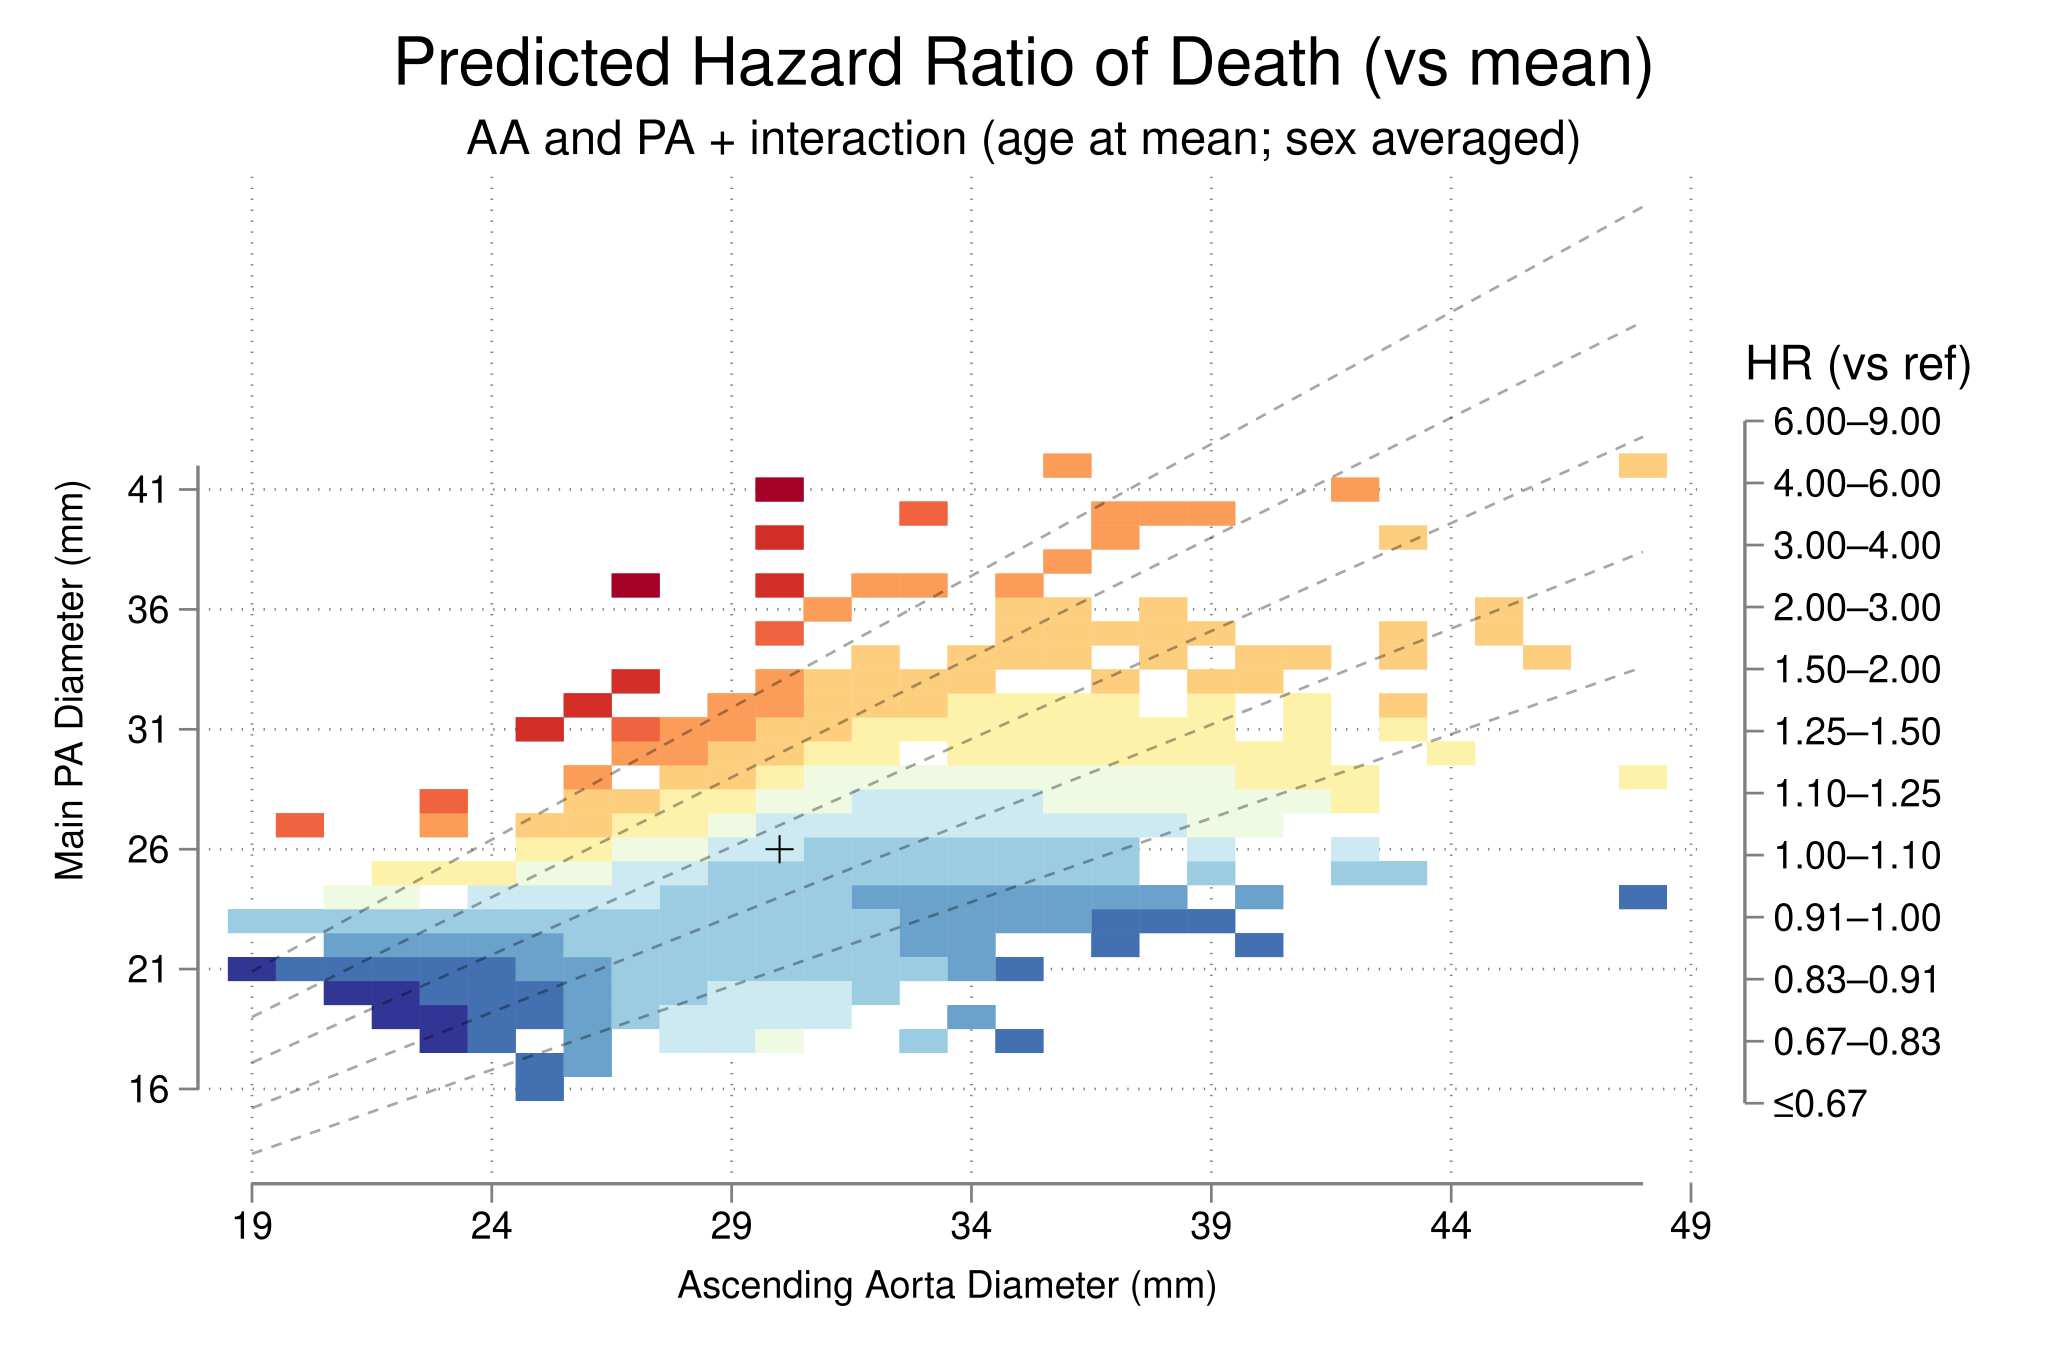

In [10]:
%%stata
preserve
/* ===== Heatmap: observed cells only | rcs(age,3); sex averaged | NO ht/wt ===== */

* 1) Setup + knots
stset lastfollowupyear, failure(death==1)

capture drop mpad_rounded aa_rounded
gen mpad_rounded = round(mpad, 0.1)
gen aa_rounded   = round(ascendingaorta, 0.1)

quietly _pctile mpad_rounded if !missing(mpad_rounded), p(10 50 90)
local k_mpad `r(r1)' `r(r2)' `r(r3)'
quietly summarize mpad_rounded, meanonly
local mp_min = r(min)
local mp_max = r(max)

quietly _pctile aa_rounded if !missing(aa_rounded), p(10 50 90)
local k_aa `r(r1)' `r(r2)' `r(r3)'
quietly summarize aa_rounded, meanonly
local aa_min = r(min)
local aa_max = r(max)

quietly _pctile age if !missing(age), p(10 50 90)
local k_age `r(r1)' `r(r2)' `r(r3)'
quietly summarize age, meanonly
local age_min = r(min)
local age_max = r(max)

* 2) Fit 2D model: rcs(PA,3)×rcs(AA,3) + rcs(age,3) + sex
capture drop mpad_rc* aa_rc* age_rc*
mkspline2 mpad_rc = mpad_rounded, cubic knots(`k_mpad')
mkspline2 aa_rc   = aa_rounded,   cubic knots(`k_aa')
mkspline2 age_rc  = age,          cubic knots(`k_age')

stcox c.(mpad_rc*)##c.(aa_rc*) c.(age_rc*) i.male, vce(robust)
estimates store M1
estat concordance
gen byte esample = e(sample)

* Holds for prediction (means on the estimation sample)
quietly summarize age  if esample, meanonly
scalar AGEbar = r(mean)
quietly summarize male if esample, meanonly
scalar PMALE  = r(mean)

* Means of PA and AA (for reference point)
quietly summarize mpad           if esample, meanonly
scalar MPAbar = r(mean)
quietly summarize ascendingaorta if esample, meanonly
scalar AAbar  = r(mean)

* 3) Observed-cell grid only
tempfile EST
save `EST', replace
use `EST', clear
keep if esample
gen mpad_cell = round(mpad, 1)
gen aa_cell   = round(ascendingaorta, 1)
contract mpad_cell aa_cell
rename mpad_cell mpad
rename aa_cell   ascendingaorta
rename _freq     Ncell

* dynamic axes from observed cells
quietly summarize mpad, meanonly
local xlo = floor(r(min))     // PA for Y axis
local xhi = ceil(r(max))
quietly summarize ascendingaorta, meanonly
local ylo = floor(r(min))     // AA for X axis
local yhi = ceil(r(max))

* duplicate per sex; age at mean
expand 2
bysort mpad ascendingaorta: gen male = _n-1
gen age = AGEbar

* add sentinels (ensure >2 age values for spline basis)
local N0 = _N
set obs `=_N + 2'
replace mpad           = 25        in `= `N0' + 1'
replace ascendingaorta = 30        in `= `N0' + 1'
replace age            = `age_min' in `= `N0' + 1'
replace male           = 0         in `= `N0' + 1'

replace mpad           = 25        in `= `N0' + 2'
replace ascendingaorta = 30        in `= `N0' + 2'
replace age            = `age_max' in `= `N0' + 2'
replace male           = 0         in `= `N0' + 2'
gen byte sentinel = (_n > `N0')

* 4) Predict on the grid; sex‑average; normalize to (MPAbar,AAbar)
gen mpad_rounded = round(mpad, 0.1)
gen aa_rounded   = round(ascendingaorta, 0.1)
mkspline2 mpad_rc = mpad_rounded, cubic knots(`k_mpad')
mkspline2 aa_rc   = aa_rounded,   cubic knots(`k_aa')
mkspline2 age_rc  = age,          cubic knots(`k_age')

estimates restore M1
predict xb, xb
gen HR = exp(xb)

drop if sentinel==1

gen w = cond(male==1, PMALE, 1-PMALE)
bysort mpad ascendingaorta: egen HRw  = total(HR*w)
bysort mpad ascendingaorta: egen wsum = total(w)
gen HR_avg = HRw/wsum

gen double d2 = (mpad - MPAbar)^2 + (ascendingaorta - AAbar)^2
bysort mpad ascendingaorta: keep if _n==1
sort d2
scalar HRREF      = HR_avg[1]
local  ref_m_used = mpad[1]
local  ref_a_used = ascendingaorta[1]
gen double normalized_HR = HR_avg/HRREF

* 5) Bin + labeled legend
capture drop hr_bin
local cuts "0.55 0.67 0.83 0.91 1 1.10 1.25 1.50 2 3 4 6 9 12 16.5"
egen hr_bin = cut(normalized_HR), at(`cuts') icodes
label define hr_lab 1 "≤0.67" 2 "0.67–0.83" 3 "0.83–0.91" 4 "0.91–1.00" ///
                    5 "1.00–1.10" 6 "1.10–1.25" 7 "1.25–1.50" 8 "1.50–2.00" ///
                    9 "2.00–3.00" 10 "3.00–4.00" 11 "4.00–6.00" 12 "6.00–9.00" ///
                    13 "9.00–12.00" 14 "≥12.00", replace
label values hr_bin hr_lab

levelsof hr_bin if hr_bin>0 & !missing(hr_bin), local(usedbins)
local ramp_labels
foreach k of local usedbins {
    local lab : label (hr_bin) `k'
    local ramp_labels `ramp_labels' `k' "`lab'"
}
local nbins : word count `usedbins'

* ratio guide lines + reference marker (X=AA, Y=PA)
local overlays
foreach r in 0.7 0.8 0.9 1.0 1.1 {
    local overlays `overlays' || ///
        function y = `r'*x, range(`ylo' `yhi') ///
        lcolor(black%35) lpattern(shortdash) lwidth(thin) legend(off)
}
local overlays `overlays' || ///
    scatter mpad ascendingaorta if mpad==`ref_m_used' & ascendingaorta==`ref_a_used', ///
    msymbol(plus) mcolor(black) msize(medlarge) legend(off)

* 6) Heatmap
heatplot hr_bin mpad ascendingaorta, discrete ///
    color(RdYlBu, reverse n(`nbins')) ///
    ramp(right subtitle("HR (vs ref)") label(`ramp_labels')) ///
    title("Predicted Hazard Ratio of Death (vs mean)") ///
    subtitle("AA and PA + interaction (age at mean; sex averaged)", size(medsmall)) ///
    xtitle("Ascending Aorta Diameter (mm)") ///
    ytitle("Main PA Diameter (mm)") ///
    xlabel(`ylo'(5)`yhi') ylabel(`xlo'(5)`xhi') ///
    scheme(white_w3d) ///
    addplot(`overlays')

* sanity checks
di "Ref cell used:  PA=" `ref_m_used' "  AA=" `ref_a_used'
list normalized_HR if mpad==`ref_m_used' & ascendingaorta==`ref_a_used'
di "Mean PA:AA ratio = " %5.3f (MPAbar/AAbar)

restore

***Interpretation:*** the predicted risk for patients on the same PA:AA line can vary quite a lot, whether it's "small PA and small AA", "normal normal", or "big big"

### Does the dual spline model predict much more accurately than the single ratio model? 

In [11]:
%%stata
preserve
/* ==== Model comparison: 1D ratio vs 2D PA×AA (adj = rcs(age,3) + sex) ==== */
stset lastfollowupyear, failure(death==1)

* Age spline
capture drop age_rc*
mkspline2 age_rc = age, cubic nknots(3)

* --- M_Ratio: rcs(PA:AA,4) on ×100 ---
capture drop paaa100 rcR*
gen long paaa100 = round(mpaaa*100)
mkspline2 rcR = paaa100, cubic nknots(4)
stcox c.(age_rc*) i.male c.(rcR*), vce(robust)

tempname S aR bR cR
quietly estat ic
matrix `S' = r(S)
scalar `aR' = `S'[1,5]
scalar `bR' = `S'[1,6]
capture noisily estat concordance
scalar `cR' = .
if (_rc==0) scalar `cR' = r(C)
capture drop rcR*

* --- M_2D: rcs(PA,3) × rcs(AA,3) + rcs(age,3) + sex
quietly _pctile mpad, p(10 50 90)
local k_mpad `r(r1)' `r(r2)' `r(r3)'
quietly _pctile ascendingaorta, p(10 50 90)
local k_aa   `r(r1)' `r(r2)' `r(r3)'

capture drop mpad_rc* aa_rc*
mkspline2 mpad_rc = mpad,          cubic knots(`k_mpad')
mkspline2 aa_rc   = ascendingaorta, cubic knots(`k_aa')

stcox c.(mpad_rc*)##c.(aa_rc*) c.(age_rc*) i.male, vce(robust)

tempname S2 a2 b2 c2
quietly estat ic
matrix `S2' = r(S)
scalar `a2' = `S2'[1,5]
scalar `b2' = `S2'[1,6]
capture noisily estat concordance
scalar `c2' = .
if (_rc==0) scalar `c2' = r(C)

* Report
matrix M = ( scalar(`aR') , scalar(`bR') , scalar(`cR') \ ///
             scalar(`a2') , scalar(`b2') , scalar(`c2') )
matrix rownames M = M_Ratio M_2D
matrix colnames M = AIC BIC C
di as txt "Model comparison: Ratio (1D) vs 2D surface  [adj: rcs(age,3)+sex]"
matlist M, format(%9.4f)

* Clean
capture drop mpad_rc* aa_rc* age_rc* paaa100
restore


. preserve

. /* ==== Model comparison: 1D ratio vs 2D PA×AA (adj = rcs(age,3) + sex) ==== 
> */
. stset lastfollowupyear, failure(death==1)

Survival-time data settings

         Failure event: death==1
Observed time interval: (0, lastfollowupyear]
     Exit on or before: failure

--------------------------------------------------------------------------
        990  total observations
         78  observations end on or before enter()
--------------------------------------------------------------------------
        912  observations remaining, representing
        263  failures in single-record/single-failure data
  6,981.359  total analysis time at risk and under observation
                                                At risk from t =         0
                                     Earliest observed entry t =         0
                                          Last observed exit t =   12.4819

. 
. * Age spline
. capture drop age_rc*

. mkspline2 age_rc = age, cubic nknots(3)



***Interpretation:*** the dual spline model is a little bit more accurate, but not enough to justify the use of all the additional degrees of freedom (model flexibility)

## Overall conclusion: 

1. AA mostly depends on age in this sample, with smaller independent contributions from sex, height, and weight... but a little more than half the variation is not explained by (linear increases in) those factors
2. In age, sex adjusted models that use PA size to predict hazard of death, normalizing by metrics of body-size works roughly as well as normalizing by AA... suggesting that AA is not encoding substantial additional prognostic information in this group.
3. If PA size and AA size are both modeled flexibly, the predicted hazard of death can vary substantially among patients with the same PA:AA values - depending on which type of PA and AA values (small small, med med, large large). However, the more complicated model is not all that much more predictive than the simple one - suggesting that in practice this distinction doesn't have much consequence. 

Therefore, as most of the prognostic information is encoded in the PA diameter itself - parsimonious models should focus on PA_diameter +/- one of the body size adjustments. 